# 官方 xinntao/ESRGAN 推理脚本 (Inference)

本 Notebook 集成 [xinntao/ESRGAN](https://github.com/xinntao/ESRGAN) 官方预训练模型，对 AWM 数据集的低分辨率图像进行 **4× 超分**。  
官方 ESRGAN 仅提供 4× 模型（RRDB_ESRGAN_x4.pth / RRDB_PSNR_x4.pth），请将权重放入 `pretrained_models/` 后运行。

- **预训练权重**： [Google Drive](https://drive.google.com/drive/u/0/folders/17VYV_SoZZesU6mbxz2dMAIccSSlqLecY) 或 [Baidu 网盘](https://pan.baidu.com/s/1-Lh6ma-wXzfH8NqeBtPaFQ)
- **结果保存**：`results/xinntao_ESRGAN_4x_inference/`

In [4]:
import os
import sys
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# 使用官方 ESRGAN 的 RRDBNet 架构（4x，23 blocks）
esrgan_path = os.path.abspath('ESRGAN')
if esrgan_path not in sys.path:
    sys.path.insert(0, esrgan_path)
import RRDBNet_arch as arch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128
CUDA: True


In [5]:
# ==========================================
# 配置参数（官方 ESRGAN 仅支持 4x）
# ==========================================
# 模型：RRDB_ESRGAN_x4.pth（感知质量）或 RRDB_PSNR_x4.pth（高 PSNR）
MODEL_NAME = 'RRDB_ESRGAN_x4.pth'
MODEL_PATH = os.path.join('pretrained_models', MODEL_NAME)

LR_DIR = 'dataset/lowres_4x/original'
HR_DIR = 'dataset/highres/original'
OUTPUT_DIR = 'results/xinntao_ESRGAN_4x_inference'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Model: {MODEL_PATH}")
print(f"LR dir: {LR_DIR}")

Device: cuda
Model: pretrained_models/RRDB_ESRGAN_x4.pth
LR dir: dataset/lowres_4x/original


In [6]:
# ==========================================
# 加载官方 ESRGAN 模型
# ==========================================
# 架构：in_nc=3, out_nc=3, nf=64, nb=23, gc=32（与官方 test.py 一致）
# 完整权重约 63 MB；若文件明显更小则可能未下载完整
EXPECTED_MIN_BYTES = 55_000_000  # ~55 MB（完整约 63 MB）

model = arch.RRDBNet(3, 3, 64, 23, gc=32)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"未找到权重: {MODEL_PATH}\n"
        "请从 https://github.com/xinntao/ESRGAN 提供的 Google Drive/Baidu 下载 RRDB_ESRGAN_x4.pth 并放入 pretrained_models/"
    )
size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
if size_mb < EXPECTED_MIN_BYTES / (1024 * 1024):
    raise FileNotFoundError(
        f"权重文件不完整: {MODEL_PATH} 当前仅 {size_mb:.2f} MB，完整约 63 MB。\n"
        "请重新完整下载（避免浏览器/网盘中断），再放入 pretrained_models/。"
    )
try:
    state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(state, strict=True)
except (RuntimeError, OSError) as e:
    if "EOF" in str(e) or "corrupted" in str(e).lower():
        raise RuntimeError(
            f"权重文件已损坏或未下载完整: {MODEL_PATH}\n"
            f"当前大小: {size_mb:.2f} MB（完整约 63 MB）。请重新完整下载后替换。\n"
            "下载: https://drive.google.com/drive/u/0/folders/17VYV_SoZZesU6mbxz2dMAIccSSlqLecY"
        ) from e
    raise
model.eval()
model = model.to(device)
print("模型加载完成。")

模型加载完成。


In [7]:
# ==========================================
# 单张推理（与官方 test.py 一致的预处理）
# ==========================================
def infer_one(lr_path, save_dir=None, tile_size=512):
    """对单张 LR 做 4x 超分。大图自动分块以防 OOM。"""
    img = cv2.imread(lr_path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = img * 1.0 / 255
    # BGR -> RGB, HWC -> CHW
    img_t = torch.from_numpy(np.transpose(img[:, :, [2, 1, 0]], (2, 0, 1))).float().unsqueeze(0).to(device)

    h, w = img_t.shape[2], img_t.shape[3]
    if h <= tile_size and w <= tile_size:
        with torch.no_grad():
            out = model(img_t).data.squeeze().float().cpu().clamp_(0, 1).numpy()
    else:
        # 分块推理
        out = np.zeros((3, h * 4, w * 4), dtype=np.float32)
        for i in range(0, h, tile_size):
            for j in range(0, w, tile_size):
                i2, j2 = min(i + tile_size, h), min(j + tile_size, w)
                patch = img_t[:, :, i:i2, j:j2].to(device)
                with torch.no_grad():
                    p = model(patch).data.squeeze().float().cpu().clamp_(0, 1).numpy()
                out[:, i*4:(i2)*4, j*4:(j2)*4] = p
    # CHW, RGB -> HWC, BGR for save
    out = np.transpose(out[[2, 1, 0], :, :], (1, 2, 0))
    out = (out * 255.0).round().astype(np.uint8)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(lr_path))[0]
        path_out = os.path.join(save_dir, f"{base}.png")
        cv2.imwrite(path_out, out)
    return out

共 434 张，结果保存至: results/xinntao_ESRGAN_4x_inference


xinntao ESRGAN 4x:   6%|▌         | 25/434 [00:38<08:32,  1.25s/it]

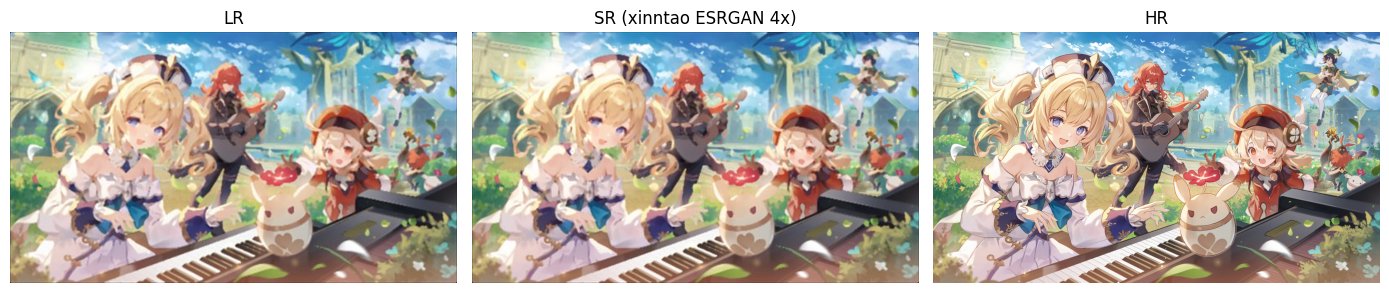

xinntao ESRGAN 4x:  32%|███▏      | 141/434 [02:57<05:45,  1.18s/it]

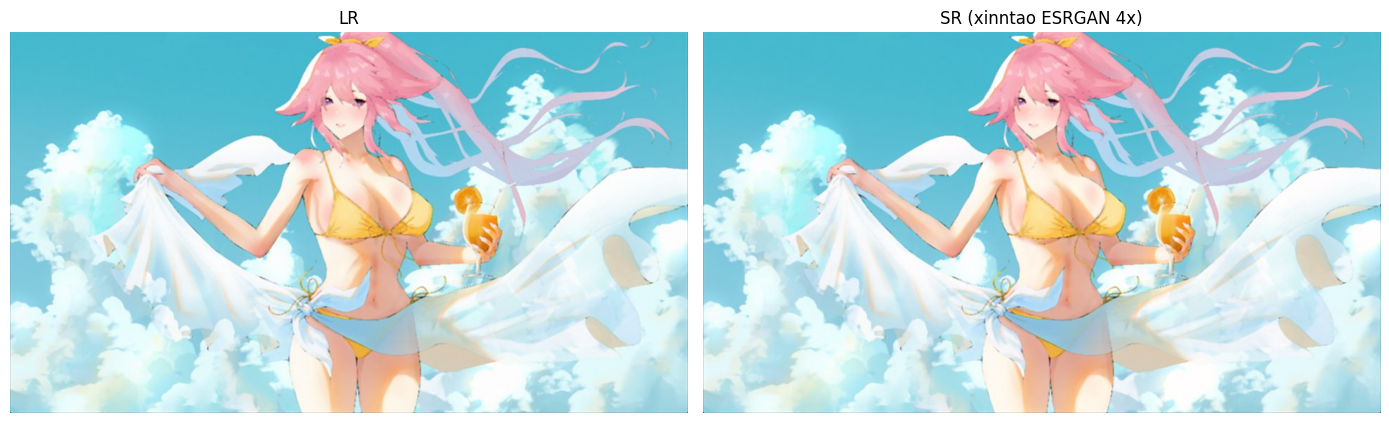

xinntao ESRGAN 4x:  87%|████████▋ | 377/434 [07:22<01:19,  1.39s/it]

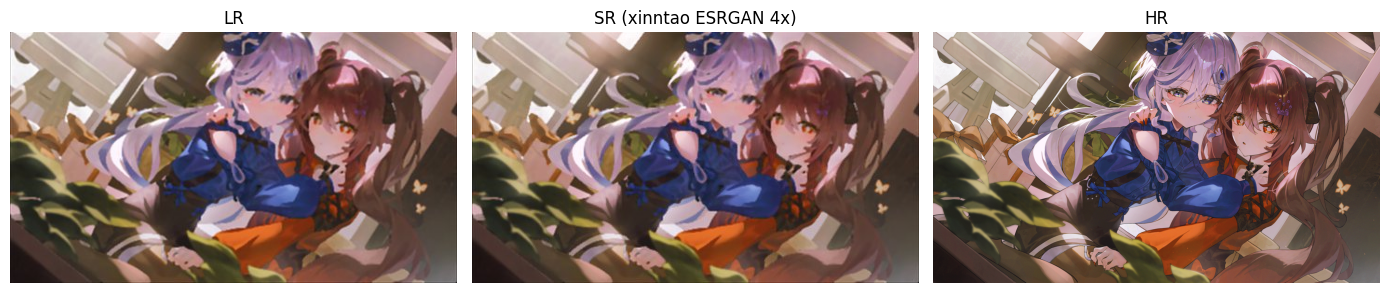

xinntao ESRGAN 4x: 100%|██████████| 434/434 [08:19<00:00,  1.15s/it]

批量推理完成。


In [8]:
# ==========================================
# 批量推理并可选可视化对比
# ==========================================
import random
from tqdm import tqdm

lr_paths = sorted(glob.glob(os.path.join(LR_DIR, '*.*')))
if not lr_paths:
    print("未找到 LR 图像，请检查路径:", LR_DIR)
else:
    num_vis = min(3, len(lr_paths))
    vis_indices = set(random.sample(range(len(lr_paths)), num_vis))
    print(f"共 {len(lr_paths)} 张，结果保存至: {OUTPUT_DIR}")

    for idx, lr_path in enumerate(tqdm(lr_paths, desc="xinntao ESRGAN 4x")):
        sr_img = infer_one(lr_path, save_dir=OUTPUT_DIR)
        if sr_img is None:
            continue
        if idx in vis_indices:
            fname = os.path.basename(lr_path)
            hr_path = os.path.join(HR_DIR, os.path.splitext(fname)[0] + os.path.splitext(fname)[1])
            fig, axes = plt.subplots(1, 3 if os.path.exists(hr_path) else 2, figsize=(14, 5))
            lr_img = cv2.imread(lr_path)
            lr_img = cv2.cvtColor(lr_img, cv2.COLOR_BGR2RGB)
            axes[0].imshow(lr_img)
            axes[0].set_title("LR")
            axes[0].axis("off")
            axes[1].imshow(cv2.cvtColor(sr_img, cv2.COLOR_BGR2RGB))
            axes[1].set_title("SR (xinntao ESRGAN 4x)")
            axes[1].axis("off")
            if os.path.exists(hr_path):
                hr_img = cv2.imread(hr_path)
                axes[2].imshow(cv2.cvtColor(hr_img, cv2.COLOR_BGR2RGB))
                axes[2].set_title("HR")
                axes[2].axis("off")
            plt.tight_layout()
            plt.show()
    print("批量推理完成。")

In [9]:
# ==========================================
# 可选：无参考质量评估 (NIQE, MANIQA, CLIPIQA)
# ==========================================
# 需要: pip install pyiqa
try:
    import pyiqa
except ImportError:
    print("未安装 pyiqa，跳过评估。可执行: pip install pyiqa")
else:
    sr_list = sorted(glob.glob(os.path.join(OUTPUT_DIR, '*.*')))
    if sr_list:
        niqe_m = pyiqa.create_metric('niqe', device=device)
        maniqa_m = pyiqa.create_metric('maniqa', device=device)
        clipiqa_m = pyiqa.create_metric('clipiqa', device=device)
        n = [niqe_m(p).item() for p in tqdm(sr_list, desc="NIQE")]
        ma = [maniqa_m(p).item() for p in tqdm(sr_list, desc="MANIQA")]
        c = [clipiqa_m(p).item() for p in tqdm(sr_list, desc="CLIPIQA")]
        print("Average NIQE (↓):", np.mean(n))
        print("Average MANIQA (↑):", np.mean(ma))
        print("Average CLIPIQA (↑):", np.mean(c))
    else:
        print("未找到输出图像，请先运行上一格批量推理。")

/home/shunyu/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shunyu/miniconda3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading pretrained model MANIQA from /home/shunyu/.cache/torch/hub/pyiqa/ckpt_koniq10k.pt


CLIPIQA: 100%|██████████| 434/434 [08:38<00:00,  1.20s/it]

Average NIQE (↓): 4.971024624568482
Average MANIQA (↑): 0.1564481475901219
Average CLIPIQA (↑): 0.22200767167152896
